# Lizard Image Classification Pipeline

This notebook follows a structured data science workflow for a TensorFlow/Keras lizard image classification project. The dataset is assumed to use a Kaggle-style image classification layout with `train/`, `test/`, `train.csv`, `test.csv`, and `sample_submission.csv`.

## 1. Project Setup

This section contains imports, project paths, constants, and random seeds. Keeping this setup in one place makes the notebook easier to reproduce and debug.

In [ ]:
# Optional installation cell. Uncomment if needed.
# %pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn pillow
# %pip install -q fiftyone cleanvision cleanlab optuna tensorboard openpyxl

In [1]:
from pathlib import Path
import gc
import inspect
import os
import random
import shutil
import warnings

import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\DLProject_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0
GPU devices: []


In [2]:
# Paths
ROOT = Path.cwd()
TRAIN_DIR = ROOT / "train"
TEST_DIR = ROOT / "test"
TRAIN_CSV = ROOT / "train.csv"
TEST_CSV = ROOT / "test.csv"
SAMPLE_SUBMISSION = ROOT / "sample_submission.csv"

ARTIFACTS_DIR = ROOT / "artifacts"
REPORT_DIR = ARTIFACTS_DIR / "reports"
WORKING_ROOT = ARTIFACTS_DIR

for directory in [ARTIFACTS_DIR, REPORT_DIR, WORKING_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (384, 384)
BACKBONE_NAME = "convnext_tiny"  # options: "convnext_tiny", "efficientnetv2s", "efficientnetb0", "efficientnetv2b0"
CONVNEXT_DROP_PATH_RATE = 0.10
LABEL_SMOOTHING = 0.10
ENSEMBLE_BACKBONES = ["convnext_tiny", "efficientnetv2s", "efficientnetb0"]
ENSEMBLE_WEIGHTS = {"convnext_tiny": 0.45, "efficientnetv2s": 0.35, "efficientnetb0": 0.20}
ENSEMBLE_MODEL_PATHS = {}  # optional: pre-trained .keras checkpoints; empty means train all ensemble backbones
ENSEMBLE_WEIGHT_OPTUNA_TRIALS = 300
ENSEMBLE_SELECTION_MODE = "robust"  # options: "manual", "optuna", "robust"
MANUAL_ENSEMBLE_WEIGHTS = {"convnext_tiny": 0.045900, "efficientnetv2s": 0.478701, "efficientnetb0": 0.475399}
ENSEMBLE_ROBUST_SELECTION_TOLERANCE = 0.005
ENSEMBLE_ROBUST_CANDIDATE_WEIGHTS = {
    "optuna": None,
    "stable_010_045_045": {"convnext_tiny": 0.10, "efficientnetv2s": 0.45, "efficientnetb0": 0.45},
    "stable_020_040_040": {"convnext_tiny": 0.20, "efficientnetv2s": 0.40, "efficientnetb0": 0.40},
    "equal_033_033_033": {"convnext_tiny": 1/3, "efficientnetv2s": 1/3, "efficientnetb0": 1/3},
    "no_convnext_000_050_050": {"convnext_tiny": 0.00, "efficientnetv2s": 0.50, "efficientnetb0": 0.50},
}

BATCH_SIZE = 24
AUTOTUNE = tf.data.AUTOTUNE

PRIMARY_METRIC = "macro_f1"
INFERENCE_SEARCH_MODE = "auto"
KNN_NEIGHBORS = [1, 3, 5, 7, 9, 11, 13, 15, 21, 31]
KNN_TEMPERATURES = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]
BLEND_ALPHAS = np.linspace(0.0, 1.0, 51)

RUN_OPTUNA = True
N_OPTUNA_TRIALS = 30
OPTUNA_HEAD_MAX_EPOCHS = 12
FINAL_HEAD_EPOCHS = 40
FINAL_USE_FINE_TUNING = True
FINAL_FINE_TUNE_LAST_N_LAYERS = 20
FINAL_FINE_TUNE_EPOCHS = 30
FINAL_FINE_TUNE_LEARNING_RATE = 5e-5
OPTUNA_SEARCH_FINE_TUNING = True
OPTUNA_FINE_TUNE_MAX_EPOCHS = 12
OPTUNA_PRUNING_WARMUP_EPOCHS = 4
OPTUNA_HYPERBAND_MIN_RESOURCE = 5
OPTUNA_HYPERBAND_MAX_RESOURCE = OPTUNA_HEAD_MAX_EPOCHS + OPTUNA_FINE_TUNE_MAX_EPOCHS
OPTUNA_HYPERBAND_REDUCTION_FACTOR = 3
OPTUNA_BATCH_CHOICES = [16, 24, 32]
OPTUNA_DENSE_CHOICES = [64, 128, 256]
OPTUNA_INFERENCE_FAMILIES = ["softmax_tta", "knn", "blend"]
OPTUNA_EMBEDDING_VARIANTS = ["orig", "flip_only", "flip_avg"]
OPTUNA_KNN_NEIGHBORS = KNN_NEIGHBORS
OPTUNA_KNN_TEMPERATURES = KNN_TEMPERATURES

print("Optuna trials:", N_OPTUNA_TRIALS)
print("Optuna fine-tuning search:", OPTUNA_SEARCH_FINE_TUNING)
assert TRAIN_DIR.exists(), f"Missing training directory: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing test directory: {TEST_DIR}"

Optuna trials: 30
Optuna fine-tuning search: True


## 2. Dataset Loading

We read the dataset folders, determine class names from the training directory, count the images, and build a dataframe with file paths and labels.

In [3]:
def list_image_files(directory, extensions=(".jpg", ".jpeg", ".png", ".bmp", ".webp")):
    return sorted([p for p in Path(directory).rglob("*") if p.suffix.lower() in extensions])


class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
class_to_id = {name: idx for idx, name in enumerate(class_names)}
id_to_class = {idx: name for name, idx in class_to_id.items()}

image_paths = list_image_files(TRAIN_DIR)
records = []
for path in image_paths:
    folder_label = path.parent.name
    records.append(
        {
            "filepath": str(path),
            "id": path.name,
            "folder_label": folder_label,
            "folder_label_id": class_to_id[folder_label],
            "file_size_kb": path.stat().st_size / 1024,
        }
    )

df = pd.DataFrame(records)

if TRAIN_CSV.exists():
    train_csv = pd.read_csv(TRAIN_CSV)
    df = df.merge(train_csv, on="id", how="left")
    df["label"] = df["label"].fillna(df["folder_label_id"]).astype(int)
else:
    train_csv = None
    df["label"] = df["folder_label_id"]

df["label_name"] = df["label"].map(id_to_class)
df.head()

,filepath,id,folder_label,folder_label_id,file_size_kb,label,label_name
0,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,990.215820,0,Black_spiny_tailed_iguana
1,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,3593.994141,0,Black_spiny_tailed_iguana
2,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,301.099609,0,Black_spiny_tailed_iguana
3,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,1531.162109,0,Black_spiny_tailed_iguana
4,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,771.500977,0,Black_spiny_tailed_iguana


In [4]:
print(f"Number of classes: {len(class_names)}")
print(f"Number of training images: {len(df):,}")
print(f"Number of competition test images: {len(list_image_files(TEST_DIR)):,}")
print("\nClass mapping:")
for class_id, class_name in id_to_class.items():
    print(f"{class_id}: {class_name}")

Number of classes: 7
Number of training images: 1,178
Number of competition test images: 326

Class mapping:
0: Black_spiny_tailed_iguana
1: Brown_anole
2: Cuban_knight_anole
3: Desert_iguana
4: Green_anole
5: Green_iguana
6: Lesser_Antillean_iguana


## 3. EDA

Exploratory Data Analysis checks the dataset structure before modeling. We use FiftyOne for interactive inspection, then document class balance, sample images, and image dimensions/aspect ratios in the notebook.

### FiftyOne Dataset Visualization

FiftyOne provides an interactive dataset browser where images, labels, metadata, and suspected issues can be inspected visually. This is especially useful for discovering label noise, near-duplicates, odd crops, watermarks, and confusing classes.

In [6]:
RUN_FIFTYONE = True  # Change to True when running locally and you want the interactive app.

if RUN_FIFTYONE:
    try:
        import fiftyone as fo

        dataset_name = "lizard-classification"
        if dataset_name in fo.list_datasets():
            fo.delete_dataset(dataset_name)

        fo_dataset = fo.Dataset(dataset_name)
        samples = []
        for row in df.itertuples():
            sample = fo.Sample(filepath=row.filepath)
            sample["ground_truth"] = fo.Classification(label=row.label_name)
            sample["file_size_kb"] = float(row.file_size_kb)
            if "width" in df.columns and pd.notna(getattr(row, "width", None)):
                sample["width"] = int(row.width)
            if "height" in df.columns and pd.notna(getattr(row, "height", None)):
                sample["height"] = int(row.height)
            samples.append(sample)

        fo_dataset.add_samples(samples)
        session = fo.launch_app(fo_dataset)
        print("FiftyOne app launched. Use the browser window to inspect samples.")
    except ImportError:
        print("FiftyOne is not installed. Install it with: %pip install fiftyone")
else:
    print("Set RUN_FIFTYONE = True to launch the interactive FiftyOne app.")

 100% |███████████████| 1178/1178 [488.8ms elapsed, 0s remaining, 2.4K samples/s]      


FiftyOne app launched. Use the browser window to inspect samples.


In [ ]:
plt.figure(figsize=(10, 4))
order = df["label_name"].value_counts().index
sns.countplot(data=df, y="label_name", order=order, palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

display(df["label_name"].value_counts().rename("count").to_frame())

In [ ]:
def show_sample_images(dataframe, n_per_class=3, seed=SEED):
    # Avoid groupby.apply here because Pandas 3.x excludes grouping columns by default.
    sampled_groups = []
    for label_name, group in dataframe.groupby("label_name", sort=True):
        sampled_groups.append(group.sample(n=min(len(group), n_per_class), random_state=seed))

    if not sampled_groups:
        print("No images available to display.")
        return

    sample_df = pd.concat(sampled_groups, ignore_index=True)
    n_cols = n_per_class
    n_rows = sample_df["label_name"].nunique()
    plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

    for i, row in enumerate(sample_df.itertuples(index=False), start=1):
        ax = plt.subplot(n_rows, n_cols, i)
        try:
            img = Image.open(row.filepath).convert("RGB")
            ax.imshow(img)
            title = str(row.label_name).replace("_", " ")
        except Exception as exc:
            title = f"Unreadable image\n{type(exc).__name__}"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(df, n_per_class=3)

In [8]:
def read_image_metadata(path):
    try:
        with Image.open(path) as img:
            return pd.Series(
                {
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "aspect_ratio": img.width / img.height,
                    "readable": True,
                    "error": None,
                }
            )
    except Exception as exc:
        return pd.Series(
            {
                "width": np.nan,
                "height": np.nan,
                "mode": None,
                "aspect_ratio": np.nan,
                "readable": False,
                "error": str(exc),
            }
        )


metadata = df["filepath"].apply(read_image_metadata)
df = pd.concat([df, metadata], axis=1)

display(df[["width", "height", "aspect_ratio", "file_size_kb"]].describe())
print("Unreadable images:", (~df["readable"]).sum())
print("Image modes:")
display(df["mode"].value_counts(dropna=False).to_frame("count"))

,width,height,aspect_ratio,file_size_kb
count,1178.000000,1178.000000,1178.000000,1178.000000
mean,1652.521222,1709.244482,1.039012,1777.821122
std,375.475587,392.883145,0.389868,1047.041489
min,282.000000,293.000000,0.449707,45.693359
25%,1536.000000,1440.500000,0.750000,957.503174
50%,1536.000000,2048.000000,0.752930,1572.221191
75%,2048.000000,2048.000000,1.333333,2515.676270
max,2048.000000,2048.000000,2.659740,6003.945312


Unreadable images: 0
Image modes:


,count
mode,
RGB,1178


## 4. Data Quality / Cleaning

This section checks for unreadable/corrupt images with Pillow and uses CleanVision to identify issues such as blurry images, dark images, duplicates, near duplicates, and outliers. Removed images are moved to `removed images/` instead of being permanently deleted.

In [9]:
# Basic issue checks that are useful before using heavier tooling.
possible_issues = {
    "unreadable": df.loc[~df["readable"], ["filepath", "error"]],
    "very_small": df.loc[(df["width"] < 128) | (df["height"] < 128), ["filepath", "width", "height"]],
    "extreme_aspect_ratio": df.loc[
        (df["aspect_ratio"] < 0.5) | (df["aspect_ratio"] > 2.0),
        ["filepath", "width", "height", "aspect_ratio"],
    ],
    "tiny_file": df.loc[df["file_size_kb"] < 10, ["filepath", "file_size_kb"]],
    "duplicate_filename": df.loc[df["id"].duplicated(keep=False), ["id", "filepath", "label_name"]],
}

for issue_name, issue_df in possible_issues.items():
    print(f"{issue_name}: {len(issue_df)}")
    display(issue_df.head())

unreadable: 0


,filepath,error


very_small: 0


,filepath,width,height


extreme_aspect_ratio: 30


,filepath,width,height,aspect_ratio
70,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,946,2048,0.461914
162,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,921,2048,0.449707
291,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,395,855,0.461988
293,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,667,1383,0.482285
301,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,959,2048,0.468262


tiny_file: 0


,filepath,file_size_kb


duplicate_filename: 0


,id,filepath,label_name


In [10]:
def verify_images(dataframe):
    rows = []
    for row in dataframe.itertuples():
        try:
            with Image.open(row.filepath) as img:
                img.verify()
            rows.append({"filepath": row.filepath, "is_valid": True, "error": None})
        except (UnidentifiedImageError, OSError, ValueError) as exc:
            rows.append({"filepath": row.filepath, "is_valid": False, "error": str(exc)})
    return pd.DataFrame(rows)


verification_df = verify_images(df)
invalid_images = verification_df.loc[~verification_df["is_valid"]]
print(f"Invalid/corrupt images detected by Pillow: {len(invalid_images)}")
display(invalid_images.head())

Invalid/corrupt images detected by Pillow: 0


,filepath,is_valid,error


In [ ]:
# Optional: move corrupt images to a quarantine folder instead of deleting them.
QUARANTINE_CORRUPT_IMAGES = False
QUARANTINE_DIR = ARTIFACTS_DIR / "quarantined_corrupt_images"

if QUARANTINE_CORRUPT_IMAGES and len(invalid_images) > 0:
    QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)
    for path in invalid_images["filepath"]:
        path = Path(path)
        target = QUARANTINE_DIR / path.name
        shutil.move(str(path), str(target))
    print(f"Moved {len(invalid_images)} files to {QUARANTINE_DIR}")
else:
    print("No files moved. Keep QUARANTINE_CORRUPT_IMAGES = False until issues are reviewed.")

In [ ]:
RUN_CLEANVISION = False  # Change to True to run image quality issue detection.

if RUN_CLEANVISION:
    try:
        from cleanvision import Imagelab

        imagelab = Imagelab(data_path=str(TRAIN_DIR))
        # n_jobs=1 is more reliable on Windows/Jupyter because multiprocessing can fail with PermissionError.
        imagelab.find_issues(n_jobs=1)

        cleanvision_issues = imagelab.issues
        cleanvision_summary = imagelab.issue_summary

        display(cleanvision_summary)
        display(cleanvision_issues.head())

        cleanvision_issues.reset_index(names="filepath").to_csv(REPORT_DIR / "cleanvision_issues.csv", index=False)
        cleanvision_summary.to_csv(REPORT_DIR / "cleanvision_issue_summary.csv", index=False)
    except ImportError:
        print("CleanVision is not installed. Install it with: %pip install cleanvision")
else:
    print("Set RUN_CLEANVISION = True to run CleanVision quality checks.")

### Same-Class Duplicate Quarantine

CleanVision detects duplicates across the full dataset. For this project, we only want to remove duplicate images when they occur inside the same specific class folder. If duplicate-looking images appear in different class folders, they are more important as potential label issues and should be reviewed manually instead of moved automatically.

The cell below keeps one image per duplicate group per class folder and moves the other duplicate files to `removed images/<class_name>/`. This preserves the removed files for documentation and recovery.

In [ ]:
MOVE_SAME_CLASS_DUPLICATES = False  # Review the preview first, then set to True to move files.
REMOVED_IMAGES_DIR = ROOT / "removed images"

# We quarantine exact and near duplicates only when they occur inside the same class folder.
DUPLICATE_ISSUE_TYPES_TO_QUARANTINE = ["exact_duplicates", "near_duplicates"]


def unique_destination_path(destination_path):
    destination_path = Path(destination_path)
    if not destination_path.exists():
        return destination_path

    counter = 1
    while True:
        candidate = destination_path.with_name(
            f"{destination_path.stem}_duplicate_{counter}{destination_path.suffix}"
        )
        if not candidate.exists():
            return candidate
        counter += 1


def get_cleanvision_duplicate_sets(imagelab, issue_types):
    duplicate_sets = []
    for issue_type in issue_types:
        issue_info = imagelab.info.get(issue_type, {})
        for duplicate_group in issue_info.get("sets", []):
            duplicate_sets.append(
                {
                    "issue_type": issue_type,
                    "filepaths": [Path(path) for path in duplicate_group],
                }
            )
    return duplicate_sets


def plan_same_class_duplicate_moves(duplicate_sets, train_dir=TRAIN_DIR):
    move_rows = []
    for group_id, duplicate_group in enumerate(duplicate_sets):
        issue_type = duplicate_group["issue_type"]
        filepaths = duplicate_group["filepaths"]

        by_class_folder = {}
        for filepath in filepaths:
            # Only consider images that are still inside the training class folders.
            if not filepath.exists() or filepath.parent.parent.resolve() != train_dir.resolve():
                continue
            by_class_folder.setdefault(filepath.parent.name, []).append(filepath)

        for class_name, class_filepaths in by_class_folder.items():
            if len(class_filepaths) < 2:
                continue

            class_filepaths = sorted(class_filepaths, key=lambda path: path.name)
            kept_filepath = class_filepaths[0]
            for moved_filepath in class_filepaths[1:]:
                target_dir = REMOVED_IMAGES_DIR / class_name
                target_path = unique_destination_path(target_dir / moved_filepath.name)
                move_rows.append(
                    {
                        "issue_type": issue_type,
                        "duplicate_group_id": group_id,
                        "class_name": class_name,
                        "kept_filepath": str(kept_filepath),
                        "moved_filepath": str(moved_filepath),
                        "target_filepath": str(target_path),
                    }
                )
    return pd.DataFrame(move_rows)


if "imagelab" not in globals():
    print("Run the CleanVision cell first so imagelab.info contains duplicate groups.")
else:
    duplicate_sets = get_cleanvision_duplicate_sets(
        imagelab,
        DUPLICATE_ISSUE_TYPES_TO_QUARANTINE,
    )
    duplicate_move_plan = plan_same_class_duplicate_moves(duplicate_sets)

    print(f"Same-class duplicate files planned for quarantine: {len(duplicate_move_plan)}")
    display(duplicate_move_plan.head(30))
    duplicate_move_plan.to_csv(REPORT_DIR / "same_class_duplicate_move_plan.csv", index=False)

    if MOVE_SAME_CLASS_DUPLICATES and not duplicate_move_plan.empty:
        moved_rows = []
        for row in duplicate_move_plan.itertuples(index=False):
            source = Path(row.moved_filepath)
            target = Path(row.target_filepath)
            target.parent.mkdir(parents=True, exist_ok=True)

            if source.exists():
                target = unique_destination_path(target)
                shutil.move(str(source), str(target))
                moved_rows.append({**row._asdict(), "target_filepath": str(target)})

        moved_duplicates_df = pd.DataFrame(moved_rows)
        moved_duplicates_df.to_csv(REPORT_DIR / "same_class_duplicates_moved.csv", index=False)
        print(f"Moved {len(moved_duplicates_df)} duplicate files to: {REMOVED_IMAGES_DIR}")
    else:
        print("No files moved. Set MOVE_SAME_CLASS_DUPLICATES = True after reviewing the plan.")

### Visual Review: Odd-Size Images

Near duplicates inside the same class are quarantined by the duplicate-cleaning cell above because they add little new information and can make validation performance too optimistic. Odd-size images are kept: the model resizes every image to the same input size, and these samples are only larger or smaller than average rather than invalid. The grid below is only a quick sanity check for odd-size images.

In [ ]:
def cleanvision_issues_with_filepaths(imagelab):
    issues = imagelab.issues.copy()
    issues["filepath"] = issues.index.astype(str)
    return issues.reset_index(drop=True)


def add_class_and_metadata(issue_df, base_df=df):
    meta_cols = ["filepath", "label_name", "width", "height", "file_size_kb"]
    available_cols = [col for col in meta_cols if col in base_df.columns]
    return issue_df.merge(base_df[available_cols], on="filepath", how="left")


def show_issue_images(issue_df, title, n=24, sort_col=None):
    review_df = issue_df.copy()
    review_df = review_df[review_df["filepath"].apply(lambda path: Path(path).exists())]
    if sort_col and sort_col in review_df.columns:
        review_df = review_df.sort_values(sort_col)
    review_df = review_df.head(n)

    if review_df.empty:
        print(f"No images to show for: {title}")
        return

    n_cols = 4
    n_rows = int(np.ceil(len(review_df) / n_cols))
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))
    for i, row in enumerate(review_df.itertuples(index=False), start=1):
        ax = plt.subplot(n_rows, n_cols, i)
        image = Image.open(row.filepath).convert("RGB")
        ax.imshow(image)
        class_name = getattr(row, "label_name", "unknown")
        width = getattr(row, "width", image.width)
        height = getattr(row, "height", image.height)
        if pd.isna(width) or pd.isna(height):
            width, height = image.width, image.height
        ax.set_title(f"{class_name}\n{int(width)}x{int(height)}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()
if "imagelab" not in globals():
    print("Run the CleanVision cell first, then run this review cell.")
else:
    review_issues = add_class_and_metadata(cleanvision_issues_with_filepaths(imagelab))

    odd_size_df = review_issues[review_issues["is_odd_size_issue"] == True] if "is_odd_size_issue" in review_issues else review_issues.iloc[0:0]
    print(f"Odd-size images to review: {len(odd_size_df)}")

    display(odd_size_df[["filepath", "label_name", "width", "height", "odd_size_score"]].head(30))
    show_issue_images(odd_size_df, "Odd-size images kept in dataset", n=24, sort_col="odd_size_score")

### Cleaning Findings

Use this section after running the cells above:

- Pillow validation checks whether files can be decoded.
- CleanVision flags quality issues such as blurry, dark, light, grayscale, odd aspect ratio, exact duplicates, and near-duplicates.
- Same-class exact and near duplicates are quarantined to `removed images/<class_name>/` because they add little extra information and can inflate validation performance.
- Cross-class duplicates should be reviewed manually because they may indicate label errors rather than files that should be removed automatically.
- Odd-size images are kept because image size differences are handled by resizing, and visual review showed these samples are still valid.
- In this project, suspicious files should be reviewed visually before removal because difficult lighting or unusual poses can still be valid examples of real lizards.

Decision rule used in this notebook: quarantine corrupt/unreadable files and same-class exact/near duplicates; keep odd-size images unless visual inspection shows that an image is invalid.

## 5. Data Preparation

We create a stratified train/validation/holdout-test split from the cleaned training set, resize images, apply the selected ImageNet backbone preprocessing inside the model, and build TensorFlow data loaders.

In [11]:
clean_df = df[df["readable"]].copy()
clean_df["file_exists"] = clean_df["filepath"].apply(lambda path: Path(path).exists())
missing_after_cleaning = clean_df[~clean_df["file_exists"]].copy()
if len(missing_after_cleaning) > 0:
    print(f"Removed {len(missing_after_cleaning)} rows for images no longer present in train/.")
    display(missing_after_cleaning[["filepath", "label_name"]].head(20))
clean_df = clean_df[clean_df["file_exists"]].drop(columns="file_exists").reset_index(drop=True)

# Met k-fold heeft Optuna geen aparte val_df meer nodig
# Alleen holdout test apart houden
train_df, holdout_test_df = train_test_split(
    clean_df,
    test_size=0.15,
    random_state=SEED,
    stratify=clean_df["label"],
)
# val_df aanmaken voor baseline (buiten Optuna)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["label"],
)

# â† alleen deze versie houden, eerste verwijderd
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(clean_df["label"].unique())),
    y=train_df["label"].values,
)
class_weight_dict = {
    class_id: float(weight)
    for class_id, weight in zip(sorted(clean_df["label"].unique()), class_weights)
}

print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Holdout test: {len(holdout_test_df):,}")
print("Class weights:", class_weight_dict)

Train: 850
Validation: 151
Holdout test: 177
Class weights: {np.int64(0): 0.9872241579558653, np.int64(1): 0.9199134199134199, np.int64(2): 1.0745891276864727, np.int64(3): 1.0745891276864727, np.int64(4): 1.0035419126328218, np.int64(5): 0.9413067552602437, np.int64(6): 1.0204081632653061}


In [12]:
def decode_and_resize(path, label=None, img_size=IMG_SIZE):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size, method=tf.image.ResizeMethod.BICUBIC)
    image = tf.cast(image, tf.float32)
    image = tf.clip_by_value(image, 0.0, 255.0)

    if label is None:
        return image
    return image, tf.cast(label, tf.int32)


def make_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
holdout_test_ds = make_dataset(holdout_test_df)

## 6. Data Augmentation

Augmentation is implemented with Keras preprocessing layers. We keep transformations realistic: flips, small rotations, mild zoom/translation, and small contrast changes. Heavy color changes are avoided because color and texture can be important visual cues for lizard species.

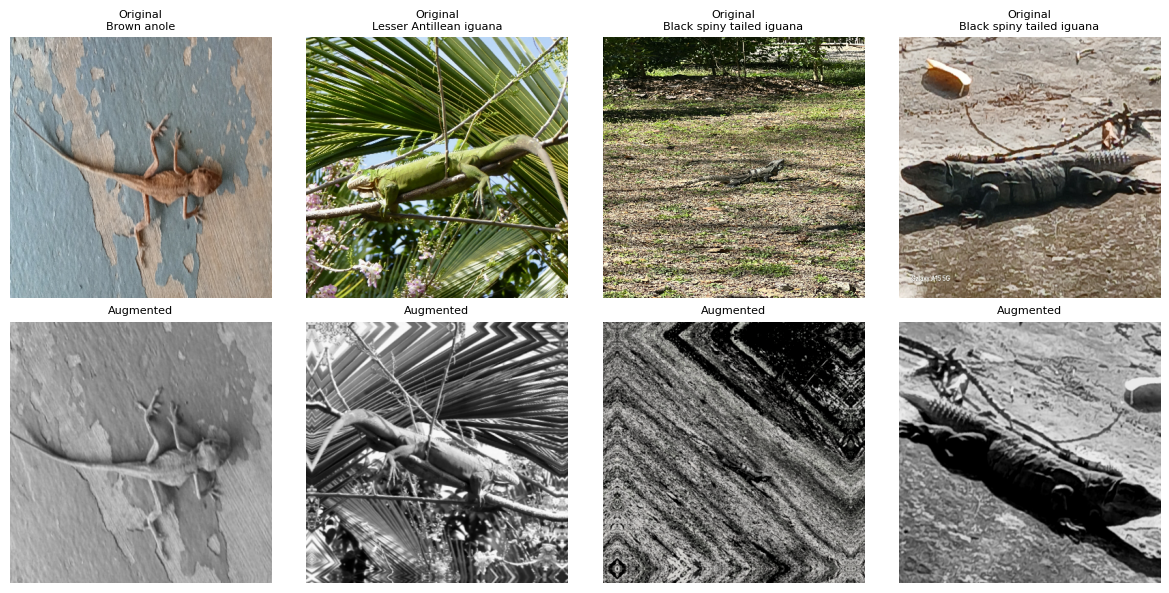

In [19]:
def make_data_augmentation():
    augmentation_layers = [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.12),
        layers.RandomZoom(0.20),
        layers.RandomContrast(0.20),
    ]
    if hasattr(layers, "RandomBrightness"):
        augmentation_layers.append(layers.RandomBrightness(0.15))
    if hasattr(layers, "RandomSaturation"):
        augmentation_layers.append(layers.RandomSaturation(0.20))
    return keras.Sequential(augmentation_layers, name="realistic_lizard_augmentation")


data_augmentation = make_data_augmentation()

plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    augmented = data_augmentation(images, training=True)
    n = min(4, images.shape[0])
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(f"Original\n{id_to_class[int(labels[i])].replace('_', ' ')}", fontsize=8)
        plt.axis("off")

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(tf.cast(tf.clip_by_value(augmented[i], 0, 255), tf.uint8))
        plt.title("Augmented", fontsize=8)
        plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Baseline Model

The baseline uses transfer learning with EfficientNetV2B0. The pretrained backbone is frozen, and we train only a custom classification head. AdamW is used by default, with Adam available as an alternative.

In [ ]:
def get_optimizer(name="adamw", learning_rate=1e-3, weight_decay=1e-4):
    name = name.lower()
    if name == "adamw":
        try:
            return keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
        except AttributeError:
            print("AdamW is unavailable in this Keras version. Falling back to Adam.")
            return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    raise ValueError(f"Unsupported optimizer: {name}")


BACKBONE_LAYER_NAMES = {
    "convnext_tiny": "convnext_tiny",
    "efficientnetb0": "efficientnetb0",
    "efficientnetv2b0": "efficientnetv2-b0",
    "efficientnetv2s": "efficientnetv2-s",
}
BACKBONE_BUILDERS = {
    "convnext_tiny": keras.applications.ConvNeXtTiny,
    "efficientnetb0": keras.applications.EfficientNetB0,
    "efficientnetv2b0": keras.applications.EfficientNetV2B0,
    "efficientnetv2s": keras.applications.EfficientNetV2S,
}
BACKBONE_LAYER_NAME = BACKBONE_LAYER_NAMES[BACKBONE_NAME]


def get_backbone_layer_name(backbone_name):
    return BACKBONE_LAYER_NAMES[backbone_name]


def make_backbone(backbone_name, img_size):
    if backbone_name not in BACKBONE_BUILDERS:
        raise ValueError(f"Unknown backbone: {backbone_name}")
    builder = BACKBONE_BUILDERS[backbone_name]
    supported_kwargs = inspect.signature(builder).parameters
    backbone_kwargs = {
        "include_top": False,
        "weights": "imagenet",
        "input_shape": (*img_size, 3),
        "pooling": "avg",
    }
    if "include_preprocessing" in supported_kwargs:
        backbone_kwargs["include_preprocessing"] = True
    if "name" in supported_kwargs:
        backbone_kwargs["name"] = get_backbone_layer_name(backbone_name)
    if backbone_name == "convnext_tiny" and "drop_path_rate" in supported_kwargs:
        backbone_kwargs["drop_path_rate"] = CONVNEXT_DROP_PATH_RATE

    try:
        return builder(**backbone_kwargs)
    except Exception as exc:
        print(f"Could not load ImageNet weights for {backbone_name}: {exc}")
        print("Falling back to random initialization. Enable internet or switch backbone if you need pretrained weights.")
        backbone_kwargs["weights"] = None
        return builder(**backbone_kwargs)


@keras.utils.register_keras_serializable(package="Lizard")
class SparseCategoricalCrossentropyWithLabelSmoothing(keras.losses.Loss):
    def __init__(
        self,
        label_smoothing=0.0,
        from_logits=False,
        reduction="sum_over_batch_size",
        name="sparse_categorical_crossentropy_with_label_smoothing",
        dtype=None,
    ):
        super().__init__(name=name, reduction=reduction, dtype=dtype)
        self.label_smoothing = float(label_smoothing)
        self.from_logits = bool(from_logits)

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, num_classes, dtype=y_pred.dtype)
        return keras.losses.categorical_crossentropy(
            y_true_one_hot,
            y_pred,
            from_logits=self.from_logits,
            label_smoothing=self.label_smoothing,
        )

    def get_config(self):
        config = super().get_config()
        config.update({"label_smoothing": self.label_smoothing, "from_logits": self.from_logits})
        return config


def sparse_categorical_crossentropy_loss(label_smoothing=LABEL_SMOOTHING):
    return SparseCategoricalCrossentropyWithLabelSmoothing(label_smoothing=label_smoothing)


def compile_classifier_model(model, learning_rate, optimizer_name="adam", weight_decay=1e-4):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate=learning_rate, weight_decay=weight_decay),
        loss=sparse_categorical_crossentropy_loss(),
        metrics=["accuracy"],
    )


def set_backbone_fine_tuning(model, fine_tune_last_n_layers=0):
    backbone_name = getattr(model, "_backbone_name", BACKBONE_NAME)
    backbone = model.get_layer(get_backbone_layer_name(backbone_name))
    fine_tune_last_n_layers = int(fine_tune_last_n_layers or 0)

    if fine_tune_last_n_layers <= 0:
        backbone.trainable = False
        for layer in backbone.layers:
            layer.trainable = False
        return

    backbone.trainable = True
    for layer in backbone.layers[:-fine_tune_last_n_layers]:
        layer.trainable = False
    for layer in backbone.layers[-fine_tune_last_n_layers:]:
        layer.trainable = True
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def build_model(
    num_classes,
    img_size=IMG_SIZE,
    dense_units=256,
    dropout_rate=0.35,
    learning_rate=3e-4,
    optimizer_name="adam",
    weight_decay=1e-4,
    backbone_name=BACKBONE_NAME,
):
    inputs = keras.Input(shape=(*img_size, 3), name="image")
    x = make_data_augmentation()(inputs)

    backbone = make_backbone(backbone_name, img_size)
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.BatchNormalization()(x)
    if dense_units > 0:
        x = layers.Dense(dense_units, activation="relu")(x)
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Activation("linear", name="embedding_features")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="class_probabilities")(x)

    model = keras.Model(inputs, outputs, name=f"lizard_{backbone_name}")
    model._backbone_name = backbone_name
    compile_classifier_model(model, learning_rate=learning_rate, optimizer_name=optimizer_name, weight_decay=weight_decay)
    return model


baseline_params = {
    "dense_units": 0,
    "dropout_rate": 0.35,
    "learning_rate": 3e-4,
    "optimizer": "adam",
    "weight_decay": 1e-4,
    "batch_size": BATCH_SIZE,
}

baseline_model = build_model(
    num_classes=len(class_names),
    dense_units=baseline_params["dense_units"],
    dropout_rate=baseline_params["dropout_rate"],
    learning_rate=baseline_params["learning_rate"],
    optimizer_name=baseline_params["optimizer"],
    weight_decay=baseline_params["weight_decay"],
    backbone_name=BACKBONE_NAME,
)
baseline_model.summary()

## 8. Baseline Training

The baseline is trained with validation monitoring, EarlyStopping, and ReduceLROnPlateau. TensorBoard logs and model checkpoints are disabled to avoid creating extra `artifacts/logs` and `artifacts/models` folders.

In [ ]:
baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

BASELINE_EPOCHS = 20

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=baseline_callbacks,
    class_weight=class_weight_dict,
)

In [ ]:
# TensorBoard logging is disabled in this notebook to avoid creating artifacts/logs.
# If needed, add keras.callbacks.TensorBoard(log_dir=...) to the callbacks manually.

## 9. Baseline Evaluation

We evaluate the baseline with training curves, a confusion matrix, and a classification report. Detailed suspicious-label/error review is handled later with Cleanlab and Grad-CAM.

In [ ]:

def plot_history(history_obj, title="Training History"):
    history_dict = history_obj.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict.get("loss", []), label="train")
    axes[0].plot(history_dict.get("val_loss", []), label="validation")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_dict.get("accuracy", []), label="train")
    axes[1].plot(history_dict.get("val_accuracy", []), label="validation")
    axes[1].set_title(f"{title}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_combined_history(head_history, fine_tune_history=None, title="Final Model Training"):
    histories = [head_history.history]
    labels = ["head training"]
    if fine_tune_history is not None:
        histories.append(fine_tune_history.history)
        labels.append("fine-tuning")

    def combine_metric(metric):
        combined = []
        for history in histories:
            combined.extend(history.get(metric, []))
        return combined

    fine_tune_start = len(histories[0].get("loss", []))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(combine_metric("loss"), label="train loss")
    axes[0].plot(combine_metric("val_loss"), label="validation loss")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(combine_metric("accuracy"), label="train accuracy")
    axes[1].plot(combine_metric("val_accuracy"), label="validation accuracy")
    val_macro_f1 = combine_metric("val_macro_f1")
    if val_macro_f1:
        axes[1].plot(val_macro_f1, label="validation macro-F1")
    axes[1].set_title(f"{title}: Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    if fine_tune_history is not None and fine_tune_start > 0:
        for axis in axes:
            axis.axvline(
                x=fine_tune_start - 0.5,
                color="red",
                linestyle="--",
                linewidth=1,
                label="fine-tune start",
            )
        handles, labels = axes[1].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        axes[1].legend(unique.values(), unique.keys())

    plt.tight_layout()
    plt.show()


def results_dataframe_from_probabilities(dataframe, probabilities):
    predictions = probabilities.argmax(axis=1)
    results = dataframe.copy().reset_index(drop=True)
    results["pred_label"] = predictions
    results["pred_name"] = results["pred_label"].map(id_to_class)
    results["confidence"] = probabilities.max(axis=1)
    return results


def predict_dataframe(model, dataset, dataframe):
    probabilities = model.predict(dataset)
    results = results_dataframe_from_probabilities(dataframe, probabilities)
    return results, probabilities


def metric_summary_from_probabilities(y_true, probabilities, name):
    predictions = probabilities.argmax(axis=1)
    return {
        "strategy": name,
        "accuracy": float(np.mean(predictions == y_true)),
        "macro_f1": float(f1_score(y_true, predictions, average="macro")),
        "weighted_f1": float(f1_score(y_true, predictions, average="weighted")),
    }


class ValidationMetricsCallback(keras.callbacks.Callback):
    def __init__(self, validation_data, validation_labels, prefix="val"):
        super().__init__()
        self.validation_data = validation_data
        self.validation_labels = np.asarray(validation_labels)
        self.prefix = prefix

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        probabilities = self.model.predict(self.validation_data, verbose=0)
        predictions = probabilities.argmax(axis=1)
        logs[f"{self.prefix}_macro_f1"] = float(
            f1_score(self.validation_labels, predictions, average="macro")
        )
        logs[f"{self.prefix}_weighted_f1"] = float(
            f1_score(self.validation_labels, predictions, average="weighted")
        )
        logs[f"{self.prefix}_eval_accuracy"] = float(
            np.mean(predictions == self.validation_labels)
        )


def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[name.replace("_", "\n") for name in class_names],
        yticklabels=[name.replace("_", "\n") for name in class_names],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def horizontal_flip_dataset(dataset):
    if isinstance(dataset.element_spec, tuple):
        return dataset.map(
            lambda images, labels: (tf.image.flip_left_right(images), labels),
            num_parallel_calls=AUTOTUNE,
        ).prefetch(AUTOTUNE)
    return dataset.map(
        lambda images: tf.image.flip_left_right(images),
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)


def build_feature_extractor(model):
    try:
        embedding_output = model.get_layer("embedding_features").output
    except ValueError:
        embedding_output = model.layers[-2].output
    return keras.Model(model.input, embedding_output, name="embedding_extractor")


def extract_embeddings(feature_model, dataset):
    return feature_model.predict(dataset, verbose=0)


def l2_normalize(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / np.maximum(norms, 1e-8)


def compute_knn_probabilities(train_embeddings, train_labels, query_embeddings, k, temperature, num_classes):
    k = min(int(k), len(train_labels))
    similarities = query_embeddings @ train_embeddings.T
    top_idx = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
    top_similarities = np.take_along_axis(similarities, top_idx, axis=1)
    order = np.argsort(-top_similarities, axis=1)
    top_idx = np.take_along_axis(top_idx, order, axis=1)
    top_similarities = np.take_along_axis(top_similarities, order, axis=1)

    weights = np.exp(top_similarities / max(float(temperature), 1e-6))
    weights = weights / np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)

    probabilities = np.zeros((len(query_embeddings), num_classes), dtype=np.float32)
    for row_idx in range(len(query_embeddings)):
        for neighbour_idx in range(k):
            label = int(train_labels[top_idx[row_idx, neighbour_idx]])
            probabilities[row_idx, label] += float(weights[row_idx, neighbour_idx])
    return probabilities


def search_inference_strategies(model, feature_model, train_eval_ds, train_labels, selection_ds, selection_labels):
    train_embeddings = l2_normalize(extract_embeddings(feature_model, train_eval_ds))
    selection_embeddings_orig = l2_normalize(extract_embeddings(feature_model, selection_ds))
    selection_embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(selection_ds)))

    base_probabilities = model.predict(selection_ds, verbose=0)
    flip_probabilities = model.predict(horizontal_flip_dataset(selection_ds), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0

    candidates = []

    def register(strategy_name, probabilities, metadata):
        summary = metric_summary_from_probabilities(selection_labels, probabilities, strategy_name)
        candidates.append({
            "strategy_name": strategy_name,
            "probabilities": probabilities,
            "metadata": metadata,
            **summary,
        })

    register("single-pass softmax", base_probabilities, {"family": "softmax"})
    register("flip-TTA softmax", tta_probabilities, {"family": "softmax_tta"})

    if INFERENCE_SEARCH_MODE == "auto":
        embedding_variants = {
            "orig": selection_embeddings_orig,
            "flip_only": selection_embeddings_flip,
            "flip_avg": l2_normalize((selection_embeddings_orig + selection_embeddings_flip) / 2.0),
        }
        for embedding_variant, query_embeddings in embedding_variants.items():
            for temperature in KNN_TEMPERATURES:
                for k in KNN_NEIGHBORS:
                    knn_probabilities = compute_knn_probabilities(
                        train_embeddings=train_embeddings,
                        train_labels=train_labels,
                        query_embeddings=query_embeddings,
                        k=k,
                        temperature=temperature,
                        num_classes=len(class_names),
                    )
                    register(
                        f"kNN only ({embedding_variant}, k={k}, temp={temperature:.2f})",
                        knn_probabilities,
                        {
                            "family": "knn",
                            "embedding_variant": embedding_variant,
                            "k": k,
                            "temperature": temperature,
                        },
                    )
                    for alpha in BLEND_ALPHAS:
                        blended_probabilities = alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities
                        register(
                            f"blend TTA + kNN ({embedding_variant}, k={k}, temp={temperature:.2f}, alpha={alpha:.2f})",
                            blended_probabilities,
                            {
                                "family": "blend",
                                "embedding_variant": embedding_variant,
                                "k": k,
                                "temperature": temperature,
                                "alpha": float(alpha),
                            },
                        )

    results_df = (
        pd.DataFrame(
            [
                {
                    "strategy": candidate["strategy_name"],
                    "accuracy": candidate["accuracy"],
                    "macro_f1": candidate["macro_f1"],
                    "weighted_f1": candidate["weighted_f1"],
                }
                for candidate in candidates
            ]
        )
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    best_candidate = max(candidates, key=lambda item: (item["macro_f1"], item["accuracy"]))
    assets = {"train_embeddings": train_embeddings, "train_labels": np.asarray(train_labels)}
    return results_df, best_candidate, assets


def predict_with_inference_strategy(model, feature_model, dataset, metadata, train_embeddings, train_labels):
    base_probabilities = model.predict(dataset, verbose=0)
    if metadata.get("family") == "softmax":
        return base_probabilities

    flip_probabilities = model.predict(horizontal_flip_dataset(dataset), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0
    if metadata.get("family") == "softmax_tta":
        return tta_probabilities

    embeddings_orig = l2_normalize(extract_embeddings(feature_model, dataset))
    embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(dataset)))
    embedding_variant = metadata.get("embedding_variant", "orig")
    if embedding_variant == "flip_only":
        query_embeddings = embeddings_flip
    elif embedding_variant == "flip_avg":
        query_embeddings = l2_normalize((embeddings_orig + embeddings_flip) / 2.0)
    else:
        query_embeddings = embeddings_orig

    knn_probabilities = compute_knn_probabilities(
        train_embeddings=train_embeddings,
        train_labels=train_labels,
        query_embeddings=query_embeddings,
        k=metadata["k"],
        temperature=metadata["temperature"],
        num_classes=len(class_names),
    )
    if metadata.get("family") == "knn":
        return knn_probabilities

    alpha = float(metadata["alpha"])
    return alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities


In [ ]:
plot_history(baseline_history, title="Baseline")

baseline_results_df, baseline_probabilities = predict_dataframe(
    baseline_model,
    holdout_test_ds,
    holdout_test_df,
)
baseline_y_true = baseline_results_df["label"].values
baseline_y_pred = baseline_results_df["pred_label"].values

print(classification_report(baseline_y_true, baseline_y_pred, target_names=class_names))
plot_confusion(baseline_y_true, baseline_y_pred, title="Baseline Confusion Matrix")

## 10. Hyperparameter Tuning

Optuna runs multiple training trials after the baseline evaluation. We tune learning rate, batch size, dropout, optimizer, dense head size, and weight decay. Hyperband prunes weak trials early to reduce wasted training time.

In [ ]:
import gc
import optuna
from sklearn.model_selection import StratifiedKFold


N_FOLDS = 5  # 3 als je sneller wil


class ValidationMetricsCallback(keras.callbacks.Callback):
    def __init__(self, validation_data, validation_labels, prefix="val"):
        super().__init__()
        self.validation_data = validation_data
        self.validation_labels = np.asarray(validation_labels)
        self.prefix = prefix

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        probabilities = self.model.predict(self.validation_data, verbose=0)
        predictions = probabilities.argmax(axis=1)
        logs[f"{self.prefix}_macro_f1"] = float(
            f1_score(self.validation_labels, predictions, average="macro")
        )


# Fallback helpers for when the baseline-evaluation cell was skipped.
# Optuna needs these for macro-F1 monitoring and TTA/kNN inference scoring.
if "ValidationMetricsCallback" not in globals():
    class ValidationMetricsCallback(keras.callbacks.Callback):
        def __init__(self, validation_data, validation_labels, prefix="val"):
            super().__init__()
            self.validation_data = validation_data
            self.validation_labels = np.asarray(validation_labels)
            self.prefix = prefix

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            probabilities = self.model.predict(self.validation_data, verbose=0)
            predictions = probabilities.argmax(axis=1)
            logs[f"{self.prefix}_macro_f1"] = float(
                f1_score(self.validation_labels, predictions, average="macro")
            )
            logs[f"{self.prefix}_weighted_f1"] = float(
                f1_score(self.validation_labels, predictions, average="weighted")
            )
            logs[f"{self.prefix}_eval_accuracy"] = float(
                np.mean(predictions == self.validation_labels)
            )


if "metric_summary_from_probabilities" not in globals():
    def metric_summary_from_probabilities(y_true, probabilities, name):
        predictions = probabilities.argmax(axis=1)
        return {
            "strategy": name,
            "accuracy": float(np.mean(predictions == y_true)),
            "macro_f1": float(f1_score(y_true, predictions, average="macro")),
            "weighted_f1": float(f1_score(y_true, predictions, average="weighted")),
        }


if "horizontal_flip_dataset" not in globals():
    def horizontal_flip_dataset(dataset):
        if isinstance(dataset.element_spec, tuple):
            return dataset.map(
                lambda images, labels: (tf.image.flip_left_right(images), labels),
                num_parallel_calls=AUTOTUNE,
            ).prefetch(AUTOTUNE)
        return dataset.map(
            lambda images: tf.image.flip_left_right(images),
            num_parallel_calls=AUTOTUNE,
        ).prefetch(AUTOTUNE)


if "build_feature_extractor" not in globals():
    def build_feature_extractor(model):
        try:
            embedding_output = model.get_layer("embedding_features").output
        except ValueError:
            embedding_output = model.layers[-2].output
        return keras.Model(model.input, embedding_output, name="embedding_extractor")


if "extract_embeddings" not in globals():
    def extract_embeddings(feature_model, dataset):
        return feature_model.predict(dataset, verbose=0)


if "l2_normalize" not in globals():
    def l2_normalize(embeddings):
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        return embeddings / np.maximum(norms, 1e-8)


if "compute_knn_probabilities" not in globals():
    def compute_knn_probabilities(train_embeddings, train_labels, query_embeddings, k, temperature, num_classes):
        k = min(int(k), len(train_labels))
        similarities = query_embeddings @ train_embeddings.T
        top_idx = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
        top_similarities = np.take_along_axis(similarities, top_idx, axis=1)
        top_labels = train_labels[top_idx]

        scaled = top_similarities / max(float(temperature), 1e-8)
        scaled = scaled - scaled.max(axis=1, keepdims=True)
        weights = np.exp(scaled)
        weights = weights / np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)

        probabilities = np.zeros((len(query_embeddings), num_classes), dtype=np.float32)
        for row_idx in range(len(query_embeddings)):
            for label, weight in zip(top_labels[row_idx], weights[row_idx]):
                probabilities[row_idx, int(label)] += float(weight)
        return probabilities


class KerasPruningCallback(keras.callbacks.Callback):
    def __init__(self, trial, monitor="val_macro_f1", step_offset=0):
        super().__init__()
        self.trial = trial
        self.monitor = monitor
        self.step_offset = int(step_offset)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is None:
            return
        self.trial.report(float(value), step=self.step_offset + epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned(f"Trial pruned at epoch {self.step_offset + epoch}.")


def make_trial_callbacks(trial, validation_data, validation_labels, step_offset=0, patience=3):
    return [
        ValidationMetricsCallback(validation_data, validation_labels),
        KerasPruningCallback(trial, monitor="val_macro_f1", step_offset=step_offset),
        keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
        ),
    ]


def probabilities_for_trial_strategy(model, train_eval_ds, train_labels, validation_ds, trial_params):
    base_probabilities = model.predict(validation_ds, verbose=0)
    family = trial_params["inference_family"]
    if family == "softmax":
        return base_probabilities

    flip_probabilities = model.predict(horizontal_flip_dataset(validation_ds), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0
    if family == "softmax_tta":
        return tta_probabilities

    feature_model = build_feature_extractor(model)
    train_embeddings = l2_normalize(extract_embeddings(feature_model, train_eval_ds))
    val_embeddings_orig = l2_normalize(extract_embeddings(feature_model, validation_ds))
    val_embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(validation_ds)))

    embedding_variant = trial_params["embedding_variant"]
    if embedding_variant == "flip_only":
        query_embeddings = val_embeddings_flip
    elif embedding_variant == "flip_avg":
        query_embeddings = l2_normalize((val_embeddings_orig + val_embeddings_flip) / 2.0)
    else:
        query_embeddings = val_embeddings_orig

    knn_probabilities = compute_knn_probabilities(
        train_embeddings=train_embeddings,
        train_labels=train_labels,
        query_embeddings=query_embeddings,
        k=trial_params["knn_k"],
        temperature=trial_params["knn_temperature"],
        num_classes=len(class_names),
    )
    if family == "knn":
        return knn_probabilities

    alpha = float(trial_params["blend_alpha"])
    return alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities


def objective(trial):
    trial_params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-4, log=True),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.35, 0.60),
        "dense_units": trial.suggest_categorical("dense_units", OPTUNA_DENSE_CHOICES),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", OPTUNA_BATCH_CHOICES),
        "use_fine_tuning": trial.suggest_categorical(
            "use_fine_tuning", [False, True] if OPTUNA_SEARCH_FINE_TUNING else [False]
        ),
        "inference_family": trial.suggest_categorical("inference_family", OPTUNA_INFERENCE_FAMILIES),
        "embedding_variant": trial.suggest_categorical("embedding_variant", OPTUNA_EMBEDDING_VARIANTS),
        "knn_k": trial.suggest_categorical("knn_k", OPTUNA_KNN_NEIGHBORS),
        "knn_temperature": trial.suggest_categorical("knn_temperature", OPTUNA_KNN_TEMPERATURES),
        "blend_alpha": trial.suggest_float("blend_alpha", 0.0, 1.0),
        "head_epochs": OPTUNA_HEAD_MAX_EPOCHS,
    }

    if trial_params["use_fine_tuning"]:
        trial_params.update({
            "fine_tune_last_n_layers": trial.suggest_categorical("fine_tune_last_n_layers", [10, 20, 40, 80]),
            "fine_tune_learning_rate": trial.suggest_float("fine_tune_learning_rate", 1e-6, 5e-5, log=True),
            "fine_tune_epochs": trial.suggest_int("fine_tune_epochs", 3, OPTUNA_FINE_TUNE_MAX_EPOCHS),
        })
    else:
        trial_params.update({
            "fine_tune_last_n_layers": 0,
            "fine_tune_learning_rate": 1e-6,
            "fine_tune_epochs": 0,
        })

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df["label"])):
        print(f"Trial {trial.number} â€” Fold {fold + 1}/{N_FOLDS}")

        fold_train_df = train_df.iloc[train_idx]
        fold_val_df = train_df.iloc[val_idx]
        fold_val_labels = fold_val_df["label"].to_numpy()
        fold_train_labels = fold_train_df["label"].to_numpy()

        fold_class_weights = dict(zip(
            range(len(class_names)),
            compute_class_weight("balanced", classes=np.unique(fold_train_labels), y=fold_train_labels)
        ))

        fold_train_ds = make_dataset(fold_train_df, batch_size=trial_params["batch_size"], shuffle=True)
        fold_train_eval_ds = make_dataset(fold_train_df, batch_size=trial_params["batch_size"], shuffle=False)
        fold_val_ds = make_dataset(fold_val_df, batch_size=trial_params["batch_size"])

        trial_model = build_model(
            num_classes=len(class_names),
            dense_units=trial_params["dense_units"],
            dropout_rate=trial_params["dropout_rate"],
            learning_rate=trial_params["learning_rate"],
            optimizer_name=trial_params["optimizer"],
            weight_decay=trial_params["weight_decay"],
        )

        try:
            trial_model.fit(
                fold_train_ds,
                validation_data=fold_val_ds,
                epochs=OPTUNA_HEAD_MAX_EPOCHS,
                callbacks=make_trial_callbacks(
                    trial,
                    validation_data=fold_val_ds,
                    validation_labels=fold_val_labels,
                    step_offset=fold * OPTUNA_HEAD_MAX_EPOCHS,
                ),
                verbose=0,
                class_weight=fold_class_weights,
            )

            if trial_params["use_fine_tuning"]:
                set_backbone_fine_tuning(trial_model, trial_params["fine_tune_last_n_layers"])
                compile_classifier_model(
                    trial_model,
                    learning_rate=trial_params["fine_tune_learning_rate"],
                    optimizer_name=trial_params["optimizer"],
                    weight_decay=trial_params["weight_decay"],
                )
                trial_model.fit(
                    fold_train_ds,
                    validation_data=fold_val_ds,
                    epochs=trial_params["fine_tune_epochs"],
                    callbacks=make_trial_callbacks(
                        trial,
                        validation_data=fold_val_ds,
                        validation_labels=fold_val_labels,
                        step_offset=fold * OPTUNA_HEAD_MAX_EPOCHS + OPTUNA_HEAD_MAX_EPOCHS,
                        patience=4,
                    ),
                    verbose=0,
                    class_weight=fold_class_weights,
                )

            val_probabilities = probabilities_for_trial_strategy(
                model=trial_model,
                train_eval_ds=fold_train_eval_ds,
                train_labels=fold_train_labels,
                validation_ds=fold_val_ds,
                trial_params=trial_params,
            )
            summary = metric_summary_from_probabilities(fold_val_labels, val_probabilities, "trial_strategy")
            fold_scores.append(summary["macro_f1"])
            print(f"Trial {trial.number} â€” Fold {fold + 1}/{N_FOLDS} â€” F1: {summary['macro_f1']:.4f}")

        finally:
            keras.backend.clear_session()
            gc.collect()

    mean_f1 = float(np.mean(fold_scores))
    print(f"Trial {trial.number} â€” Gemiddelde F1: {mean_f1:.4f} (folds: {[round(s, 4) for s in fold_scores]})")
    trial.set_user_attr("macro_f1", mean_f1)
    trial.set_user_attr("fold_scores", fold_scores)
    trial.set_user_attr("trial_params", trial_params)
    return mean_f1


if RUN_OPTUNA:
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.NopPruner(),  # geen pruning
        study_name="lizard_macro_f1_training_and_inference_tuning",
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    optuna_best_params = dict(study.best_params)
    optuna_best_score = float(study.best_value)
    optuna_best_user_attrs = dict(study.best_trial.user_attrs)

    print("Best validation macro-F1 found by Optuna:", optuna_best_score)
    print("Best validation metrics:")
    display(pd.DataFrame([{k: v for k, v in optuna_best_user_attrs.items() if k != "trial_params"}]))
    print("Best parameters found by Optuna:")
    display(pd.DataFrame([optuna_best_params]))
else:
    optuna_best_params = None
    optuna_best_score = None
    optuna_best_user_attrs = {}
    print("Optuna skipped. Final training will use the hardcoded parameters.")

## 11. Final Model Training

The final model uses the selected parameters hardcoded directly below, so this section can be executed without rerunning the Optuna search. The custom head is trained with the selected backbone frozen, then the top backbone layers are fine-tuned with a smaller learning rate. The holdout test split remains untouched for final local evaluation.

In [ ]:
# Hardcoded parameters so final training can be rerun without launching the Optuna search.
BEST_PARAMS = {
    "learning_rate": 5e-4,
    "dropout_rate": 0.50,
    "dense_units": 0,
    "optimizer": "adamw",
    "weight_decay": 1.4263660907094013e-05,
    "batch_size": 16,
    "use_fine_tuning": True,
    "head_epochs": 40,
    "fine_tune_last_n_layers": 20,
    "fine_tune_learning_rate": 5e-5,
    "fine_tune_epochs": 30,
}

print("Hardcoded parameters used for final training.")

if FINAL_USE_FINE_TUNING:
    BEST_PARAMS["use_fine_tuning"] = True
    BEST_PARAMS["fine_tune_last_n_layers"] = int(BEST_PARAMS.get("fine_tune_last_n_layers", FINAL_FINE_TUNE_LAST_N_LAYERS) or FINAL_FINE_TUNE_LAST_N_LAYERS)
    BEST_PARAMS["fine_tune_learning_rate"] = float(BEST_PARAMS.get("fine_tune_learning_rate", FINAL_FINE_TUNE_LEARNING_RATE) or FINAL_FINE_TUNE_LEARNING_RATE)
    BEST_PARAMS["fine_tune_epochs"] = int(BEST_PARAMS.get("fine_tune_epochs", FINAL_FINE_TUNE_EPOCHS) or FINAL_FINE_TUNE_EPOCHS)

FINAL_HEAD_EPOCHS = int(BEST_PARAMS["head_epochs"])
BEST_PARAMS["head_epochs"] = FINAL_HEAD_EPOCHS
display(pd.DataFrame([BEST_PARAMS]))

BEST_BATCH_SIZE = int(BEST_PARAMS["batch_size"])
final_train_df = train_df.copy()
final_train_ds = make_dataset(final_train_df, batch_size=BEST_BATCH_SIZE, shuffle=True)
final_val_ds = make_dataset(val_df, batch_size=BEST_BATCH_SIZE)
final_holdout_ds = make_dataset(holdout_test_df, batch_size=BEST_BATCH_SIZE)
final_class_weights = class_weight_dict
final_val_labels = val_df["label"].to_numpy()
trained_model_paths = {}
training_histories = {}


if "ValidationMetricsCallback" not in globals():
    class ValidationMetricsCallback(keras.callbacks.Callback):
        def __init__(self, validation_data, validation_labels, prefix="val"):
            super().__init__()
            self.validation_data = validation_data
            self.validation_labels = np.asarray(validation_labels)
            self.prefix = prefix

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            probabilities = self.model.predict(self.validation_data, verbose=0)
            predictions = probabilities.argmax(axis=1)
            logs[f"{self.prefix}_macro_f1"] = float(f1_score(self.validation_labels, predictions, average="macro"))


def make_final_callbacks(checkpoint_path, patience=6):
    return [
        ValidationMetricsCallback(final_val_ds, final_val_labels),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_macro_f1",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def train_one_backbone(backbone_name):
    checkpoint_path = WORKING_ROOT / f"best_lizard_model_{backbone_name}.keras"
    external_checkpoint = ENSEMBLE_MODEL_PATHS.get(backbone_name)
    if external_checkpoint and Path(external_checkpoint).exists():
        print(f"Using pre-trained checkpoint for {backbone_name}: {external_checkpoint}")
        return Path(external_checkpoint), None, None

    print(f"\n=== Training ensemble backbone: {backbone_name} ===")
    model = build_model(
        num_classes=len(class_names),
        dense_units=int(BEST_PARAMS["dense_units"]),
        dropout_rate=float(BEST_PARAMS["dropout_rate"]),
        learning_rate=float(BEST_PARAMS["learning_rate"]),
        optimizer_name=BEST_PARAMS["optimizer"],
        weight_decay=float(BEST_PARAMS["weight_decay"]),
        backbone_name=backbone_name,
    )

    head_history = model.fit(
        final_train_ds,
        validation_data=final_val_ds,
        epochs=int(BEST_PARAMS["head_epochs"]),
        callbacks=make_final_callbacks(checkpoint_path),
        class_weight=final_class_weights,
        verbose=1,
    )

    if bool(BEST_PARAMS.get("use_fine_tuning", False)):
        set_backbone_fine_tuning(model, int(BEST_PARAMS["fine_tune_last_n_layers"]))
        compile_classifier_model(
            model,
            learning_rate=float(BEST_PARAMS["fine_tune_learning_rate"]),
            optimizer_name=BEST_PARAMS["optimizer"],
            weight_decay=float(BEST_PARAMS["weight_decay"]),
        )
        fine_tune_history = model.fit(
            final_train_ds,
            validation_data=final_val_ds,
            epochs=int(BEST_PARAMS["fine_tune_epochs"]),
            callbacks=make_final_callbacks(checkpoint_path, patience=6),
            class_weight=final_class_weights,
            verbose=1,
        )
    else:
        fine_tune_history = None

    if checkpoint_path.exists():
        print("Saved best checkpoint:", checkpoint_path)
    else:
        model.save(checkpoint_path)
        print("Saved final model because no best checkpoint was written:", checkpoint_path)

    del model
    gc.collect()
    keras.backend.clear_session()
    return checkpoint_path, head_history, fine_tune_history


for backbone_name in ENSEMBLE_BACKBONES:
    checkpoint_path, head_history, fine_tune_history = train_one_backbone(backbone_name)
    trained_model_paths[backbone_name] = checkpoint_path
    training_histories[backbone_name] = {"head": head_history, "fine_tune": fine_tune_history}

print("Ensemble checkpoints:")
print(pd.Series({name: str(path) for name, path in trained_model_paths.items()}))
print("Primary training selection metric: validation macro-F1")

## 12. Final Evaluation

We evaluate the final model on the untouched holdout split, show the final training curves, confusion matrix, and classification report, and create the Kaggle submission file. Suspicious high-confidence errors are reviewed in the Cleanlab label-check section.

In [ ]:
for backbone_name, histories in training_histories.items():
    if histories["head"] is not None:
        plot_combined_history(histories["head"], histories["fine_tune"], title=f"{backbone_name} Training")


def predict_softmax_tta(model, dataset):
    if USE_TTA:
        return (
            model.predict(dataset, verbose=0) + model.predict(horizontal_flip_dataset(dataset), verbose=0)
        ) / 2.0
    return model.predict(dataset, verbose=0)


def load_trained_model(backbone_name):
    model = keras.models.load_model(trained_model_paths[backbone_name], compile=False)
    model._backbone_name = backbone_name
    return model


def collect_backbone_probabilities(dataset):
    probabilities = {}
    for backbone_name in ENSEMBLE_BACKBONES:
        model = load_trained_model(backbone_name)
        probabilities[backbone_name] = predict_softmax_tta(model, dataset)
        del model
        gc.collect()
        keras.backend.clear_session()
    return probabilities


def blend_probabilities(probabilities_by_backbone, weights):
    blended = None
    total_weight = 0.0
    for backbone_name in ENSEMBLE_BACKBONES:
        weight = float(weights.get(backbone_name, 0.0))
        if weight <= 0:
            continue
        model_probabilities = probabilities_by_backbone[backbone_name]
        blended = model_probabilities * weight if blended is None else blended + model_probabilities * weight
        total_weight += weight
    if blended is None or total_weight <= 0:
        raise ValueError("At least one ensemble weight must be positive.")
    return blended / total_weight


def evaluate_ensemble_weights(probabilities_by_backbone, labels, weights, name="ensemble"):
    probabilities = blend_probabilities(probabilities_by_backbone, weights)
    summary = metric_summary_from_probabilities(labels, probabilities, name)
    return {**summary, **{f"w_{backbone_name}": float(weights.get(backbone_name, 0.0)) for backbone_name in ENSEMBLE_BACKBONES}, "probabilities": probabilities}


def normalize_ensemble_weights(raw_weights):
    total = sum(max(0.0, float(weight)) for weight in raw_weights.values())
    if total <= 0:
        return {backbone_name: 1.0 / len(raw_weights) for backbone_name in raw_weights}
    return {backbone_name: max(0.0, float(weight)) / total for backbone_name, weight in raw_weights.items()}


def optuna_search_ensemble_weights(probabilities_by_backbone, labels, n_trials=300):
    trials = []

    def objective(trial):
        raw_weights = {
            backbone_name: trial.suggest_float(f"w_{backbone_name}", 0.0, 1.0)
            for backbone_name in ENSEMBLE_BACKBONES
        }
        weights = normalize_ensemble_weights(raw_weights)
        probabilities = blend_probabilities(probabilities_by_backbone, weights)
        predictions = probabilities.argmax(axis=1)
        macro_f1 = float(f1_score(labels, predictions, average="macro"))
        accuracy = float(np.mean(predictions == labels))
        weighted_f1 = float(f1_score(labels, predictions, average="weighted"))
        trial.set_user_attr("weights", weights)
        trial.set_user_attr("accuracy", accuracy)
        trial.set_user_attr("weighted_f1", weighted_f1)
        trials.append(
            {
                "strategy": "optuna weighted ensemble",
                "macro_f1": macro_f1,
                "accuracy": accuracy,
                "weighted_f1": weighted_f1,
                **{f"w_{backbone_name}": weights[backbone_name] for backbone_name in ENSEMBLE_BACKBONES},
            }
        )
        return macro_f1

    sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=int(n_trials), show_progress_bar=True)
    results_df = pd.DataFrame(trials).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    best_weights = dict(study.best_trial.user_attrs["weights"])
    return study, results_df, best_weights


val_probabilities_by_backbone = collect_backbone_probabilities(final_val_ds)
val_labels = val_df["label"].to_numpy()
holdout_labels = holdout_test_df["label"].to_numpy()

single_model_validation_table = pd.DataFrame([
    metric_summary_from_probabilities(val_labels, val_probabilities_by_backbone[backbone_name], f"{backbone_name} flip-TTA softmax")
    for backbone_name in ENSEMBLE_BACKBONES
]).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(single_model_validation_table)

ensemble_weight_study, ensemble_results_df, selected_ensemble_weights = optuna_search_ensemble_weights(
    val_probabilities_by_backbone,
    val_labels,
    n_trials=ENSEMBLE_WEIGHT_OPTUNA_TRIALS,
)
ENSEMBLE_WEIGHTS.update(selected_ensemble_weights)

print(f"Best Optuna ensemble macro-F1: {ensemble_weight_study.best_value:.4f}")
print("Top Optuna ensemble weights:")
display(ensemble_results_df.head(10))
print("Optuna selected ensemble weights:", selected_ensemble_weights)

robust_candidate_rows = []
for candidate_name, candidate_weights in ENSEMBLE_ROBUST_CANDIDATE_WEIGHTS.items():
    weights = selected_ensemble_weights if candidate_weights is None else normalize_ensemble_weights(candidate_weights)
    summary = evaluate_ensemble_weights(val_probabilities_by_backbone, val_labels, weights, name=candidate_name)
    summary.pop("probabilities", None)
    summary["min_weight"] = min(weights.values())
    robust_candidate_rows.append(summary)

robust_candidate_results_df = pd.DataFrame(robust_candidate_rows).sort_values(
    ["macro_f1", "accuracy", "min_weight"], ascending=False
).reset_index(drop=True)
display(robust_candidate_results_df)

optuna_macro_f1 = float(robust_candidate_results_df.loc[robust_candidate_results_df["strategy"] == "optuna", "macro_f1"].iloc[0])
if ENSEMBLE_SELECTION_MODE == "manual":
    selected_ensemble_weights = normalize_ensemble_weights(MANUAL_ENSEMBLE_WEIGHTS)
    selected_ensemble_strategy = "manual_optuna_weights"
    print("Using manual ensemble weights:", selected_ensemble_weights)
elif ENSEMBLE_SELECTION_MODE == "optuna":
    selected_ensemble_strategy = "optuna"
    print("Using raw Optuna ensemble weights.")
elif ENSEMBLE_SELECTION_MODE == "robust":
    robust_close_candidates = robust_candidate_results_df[
        (robust_candidate_results_df["strategy"] != "optuna")
        & (robust_candidate_results_df["macro_f1"] >= optuna_macro_f1 - ENSEMBLE_ROBUST_SELECTION_TOLERANCE)
    ].copy()
    if len(robust_close_candidates) > 0:
        chosen_row = robust_close_candidates.sort_values(["macro_f1", "min_weight", "accuracy"], ascending=False).iloc[0]
        selected_ensemble_weights = {backbone_name: float(chosen_row[f"w_{backbone_name}"]) for backbone_name in ENSEMBLE_BACKBONES}
        selected_ensemble_strategy = str(chosen_row["strategy"])
        print(
            f"Using robust ensemble weights from {selected_ensemble_strategy}; "
            f"within {ENSEMBLE_ROBUST_SELECTION_TOLERANCE:.3f} macro-F1 of Optuna."
        )
    else:
        selected_ensemble_strategy = "optuna"
        print("Using Optuna ensemble weights; no robust candidate was close enough.")
else:
    raise ValueError(f"Unsupported ENSEMBLE_SELECTION_MODE: {ENSEMBLE_SELECTION_MODE}")
ENSEMBLE_WEIGHTS.update(selected_ensemble_weights)
print("Final selected ensemble strategy:", selected_ensemble_strategy)
print("Final selected ensemble weights:", selected_ensemble_weights)

final_val_probabilities = blend_probabilities(val_probabilities_by_backbone, selected_ensemble_weights)
validation_metric_table = pd.concat(
    [
        single_model_validation_table,
        pd.DataFrame([metric_summary_from_probabilities(val_labels, final_val_probabilities, "optimized weighted ensemble")]),
    ],
    ignore_index=True,
).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(validation_metric_table)

holdout_probabilities_by_backbone = collect_backbone_probabilities(final_holdout_ds)
final_holdout_probabilities = blend_probabilities(holdout_probabilities_by_backbone, selected_ensemble_weights)
holdout_metric_table = pd.concat(
    [
        pd.DataFrame([
            metric_summary_from_probabilities(holdout_labels, holdout_probabilities_by_backbone[backbone_name], f"{backbone_name} flip-TTA softmax")
            for backbone_name in ENSEMBLE_BACKBONES
        ]),
        pd.DataFrame([metric_summary_from_probabilities(holdout_labels, final_holdout_probabilities, "optimized weighted ensemble")]),
    ],
    ignore_index=True,
).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(holdout_metric_table)

final_results_df = results_dataframe_from_probabilities(holdout_test_df, final_holdout_probabilities)
final_y_true = final_results_df["label"].values
final_y_pred = final_results_df["pred_label"].values

print(classification_report(final_y_true, final_y_pred, target_names=class_names))
plot_confusion(final_y_true, final_y_pred, title="Optimized Ensemble Holdout Confusion Matrix")

In [ ]:
def make_test_dataframe(test_dir=TEST_DIR, test_csv=TEST_CSV):
    test_paths = list_image_files(test_dir)
    test_df = pd.DataFrame({"filepath": [str(p) for p in test_paths], "filename": [p.name for p in test_paths]})

    if test_csv.exists():
        meta = pd.read_csv(test_csv)
        meta["filename"] = meta["id"].astype(str) + ".jpg"
        test_df = meta.merge(test_df, on="filename", how="left")
    else:
        test_df["id"] = test_df["filename"].str.replace(".jpg", "", regex=False)

    return test_df


def make_inference_dataset(dataframe, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].astype(str).values
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda path: decode_and_resize(path), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


def predict_weighted_ensemble(dataset, model_paths=None, weights=None):
    model_paths = model_paths or trained_model_paths
    weights = weights or selected_ensemble_weights
    missing = [backbone_name for backbone_name in ENSEMBLE_BACKBONES if backbone_name not in model_paths]
    if missing:
        raise ValueError(f"Missing ensemble checkpoints for: {missing}")

    probabilities = None
    total_weight = 0.0
    for backbone_name in ENSEMBLE_BACKBONES:
        model_path = Path(model_paths[backbone_name])
        if not model_path.exists():
            raise FileNotFoundError(f"Checkpoint for {backbone_name} not found at {model_path}")

        ensemble_model = keras.models.load_model(model_path, compile=False)
        weight = float(weights.get(backbone_name, 0.0))
        model_probabilities = predict_softmax_tta(ensemble_model, dataset)
        probabilities = model_probabilities * weight if probabilities is None else probabilities + model_probabilities * weight
        total_weight += weight
        print(f"Added {backbone_name} to ensemble with weight {weight:.3f}.")
        del ensemble_model
        gc.collect()
        keras.backend.clear_session()

    if probabilities is None or total_weight <= 0:
        raise ValueError("No positive ensemble weights were found.")
    return probabilities / total_weight


competition_test_df = make_test_dataframe()
assert competition_test_df["filepath"].notna().all(), "Some test ids could not be matched to image files."

competition_test_ds = make_inference_dataset(competition_test_df, batch_size=BEST_BATCH_SIZE)
submission_probabilities = predict_weighted_ensemble(competition_test_ds)
print("Submission inference strategy: optimized weighted backbone ensemble")
print("Submission ensemble strategy:", selected_ensemble_strategy)
print("Submission ensemble weights:", selected_ensemble_weights)

submission_labels = submission_probabilities.argmax(axis=1)
submission = competition_test_df[["id"]].copy()
submission["label"] = submission_labels.astype(int)

submission_path = ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)
display(submission.head())
print(f"Saved submission to: {submission_path}")

## 13. Cleanlab Label Check

Cleanlab compares model prediction probabilities with the original labels to flag samples that may be mislabeled. These examples should be manually reviewed before changing the dataset.

In [ ]:
try:
    from cleanlab.filter import find_label_issues

    label_issue_indices = find_label_issues(
        labels=final_y_true,
        pred_probs=final_holdout_probabilities,
        return_indices_ranked_by="self_confidence",
    )

    issue_probabilities = final_holdout_probabilities[label_issue_indices]
    issue_true_labels = final_y_true[label_issue_indices]
    issue_pred_labels = issue_probabilities.argmax(axis=1)
    issue_true_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_true_labels]
    issue_pred_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_pred_labels]

    cleanlab_issues = final_results_df.iloc[label_issue_indices].copy().reset_index(drop=True)
    cleanlab_issues["cleanlab_rank"] = np.arange(1, len(cleanlab_issues) + 1)
    cleanlab_issues["current_label"] = cleanlab_issues["label_name"]
    cleanlab_issues["suggested_label"] = [id_to_class[int(label)] for label in issue_pred_labels]
    cleanlab_issues["current_label_probability"] = issue_true_confidence
    cleanlab_issues["suggested_label_probability"] = issue_pred_confidence
    cleanlab_issues["issue_score"] = 1.0 - cleanlab_issues["current_label_probability"]
    cleanlab_issues["filename"] = cleanlab_issues["filepath"].apply(lambda path: Path(path).name)
    cleanlab_issues["needs_review"] = cleanlab_issues["current_label"] != cleanlab_issues["suggested_label"]
    cleanlab_issues = cleanlab_issues.sort_values(
        ["needs_review", "issue_score"],
        ascending=[False, False],
    )
    cleanlab_issues = cleanlab_issues[
        [
            "cleanlab_rank",
            "filename",
            "filepath",
            "current_label",
            "suggested_label",
            "current_label_probability",
            "suggested_label_probability",
            "issue_score",
            "needs_review",
        ]
    ]

    print(f"Potential label issues found: {len(cleanlab_issues)}")
    with pd.option_context("display.max_colwidth", None):
        display(cleanlab_issues.head(30))
    cleanlab_issues.to_csv(REPORT_DIR / "cleanlab_label_issues.csv", index=False)

    try:
        import fiftyone as fo

        fo_dataset_name = "cleanlab-label-review"
        if fo_dataset_name in fo.list_datasets():
            fo.delete_dataset(fo_dataset_name)

        review_dataset = fo.Dataset(fo_dataset_name)
        samples = []
        for row in cleanlab_issues.itertuples(index=False):
            sample = fo.Sample(filepath=row.filepath)
            sample["current_label"] = fo.Classification(
                label=row.current_label,
                confidence=float(row.current_label_probability),
            )
            sample["suggested_label"] = fo.Classification(
                label=row.suggested_label,
                confidence=float(row.suggested_label_probability),
            )
            sample["cleanlab_rank"] = int(row.cleanlab_rank)
            sample["issue_score"] = float(row.issue_score)
            sample["needs_review"] = bool(row.needs_review)
            sample["review_hint"] = f"current: {row.current_label} | suggested: {row.suggested_label}"
            sample.tags.append("possible_label_issue")
            if row.needs_review:
                sample.tags.append("label_mismatch")
            samples.append(sample)

        review_dataset.add_samples(samples)
        review_view = review_dataset.sort_by("issue_score", reverse=True)
        session = fo.launch_app(review_view)
        print("FiftyOne Cleanlab review opened.")
        print("Fields to compare: current_label = existing/true label, suggested_label = model/Cleanlab suggestion.")
        print("Sort key: issue_score. Higher means the current label received lower model probability.")
    except ImportError:
        print("FiftyOne is not installed, so only the Cleanlab table/CSV was created.")
except ImportError:
    print("Cleanlab is not installed. Install it with: %pip install cleanlab")


## 14. Optional Retraining After Label Cleaning

Only run this section if labels or training data are actually changed after manual review. The goal is to compare the cleaned-data model against the previous final model.

In [ ]:
RUN_RETRAIN_AFTER_LABEL_CLEANING = False

if RUN_RETRAIN_AFTER_LABEL_CLEANING:
    # Fill this list only after manual review of Cleanlab/CleanVision findings.
    confirmed_bad_filepaths = []

    cleaned_final_train_df = final_train_df[
        ~final_train_df["filepath"].isin(confirmed_bad_filepaths)
    ].copy()
    cleaned_final_train_ds = make_dataset(
        cleaned_final_train_df,
        batch_size=BEST_BATCH_SIZE,
        shuffle=True,
    )

    cleaned_final_model = build_model(
        num_classes=len(class_names),
        dense_units=BEST_PARAMS["dense_units"],
        dropout_rate=BEST_PARAMS["dropout_rate"],
        learning_rate=BEST_PARAMS["learning_rate"],
        optimizer_name=BEST_PARAMS["optimizer"],
        weight_decay=BEST_PARAMS["weight_decay"],
    )

    cleaned_history = cleaned_final_model.fit(
        cleaned_final_train_ds,
        epochs=FINAL_EPOCHS,
        callbacks=final_callbacks,
        class_weight=class_weight_dict,
    )

    cleaned_results_df, cleaned_probabilities = predict_dataframe(
        cleaned_final_model,
        final_holdout_ds,
        holdout_test_df,
    )
    cleaned_y_pred = cleaned_results_df["pred_label"].values
    print(classification_report(final_y_true, cleaned_y_pred, target_names=class_names))
else:
    print("Skipping retraining because no confirmed label/data changes were applied.")

## 15. Explainability / Bonus

Grad-CAM visualizes which image regions influenced predictions. We show examples for correct and incorrect predictions to check whether the model focuses on the lizard rather than background artifacts.

In [ ]:
def find_last_conv_layer(model_or_layer):
    for layer in reversed(model_or_layer.layers):
        if isinstance(layer, keras.Model):
            nested = find_last_conv_layer(layer)
            if nested is not None:
                return nested
        if isinstance(layer, layers.Conv2D):
            return layer
    return None


def call_layer(layer, x, training=False):
    try:
        return layer(x, training=training)
    except TypeError:
        return layer(x)


def make_gradcam_heatmap(img_array, model, class_index=None):
    backbone_name = getattr(model, "_backbone_name", BACKBONE_NAME)
    backbone = model.get_layer(get_backbone_layer_name(backbone_name))
    last_conv_layer = find_last_conv_layer(backbone)
    if last_conv_layer is None:
        raise ValueError("Could not find a Conv2D layer for Grad-CAM.")

    backbone_feature_model = keras.Model(
        backbone.inputs,
        [last_conv_layer.output, backbone.output],
    )
    backbone_index = model.layers.index(backbone)

    with tf.GradientTape() as tape:
        x = img_array
        for layer in model.layers[1:backbone_index]:
            x = call_layer(layer, x, training=False)

        conv_outputs, x = backbone_feature_model(x, training=False)

        for layer in model.layers[backbone_index + 1:]:
            x = call_layer(layer, x, training=False)

        predictions = x
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()


def load_image_for_model(path):
    image = decode_and_resize(tf.constant(str(path)))
    return tf.expand_dims(image, axis=0)


def show_gradcam(path, model, title_prefix="", alpha=0.35):
    img_array = load_image_for_model(path)
    heatmap, predictions = make_gradcam_heatmap(img_array, model)
    pred_idx = int(predictions[0].argmax())

    original = Image.open(path).convert("RGB").resize(IMG_SIZE)
    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE)
    heatmap_colored = plt.cm.jet(np.array(heatmap_resized) / 255.0)[:, :, :3]
    overlay = np.uint8((1 - alpha) * np.array(original) + alpha * 255 * heatmap_colored)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original)
    axes[0].set_title(f"{title_prefix}Original")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM: {id_to_class[pred_idx].replace('_', ' ')}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


if "EXPLAINABILITY_BACKBONE" not in globals():
    EXPLAINABILITY_BACKBONE = single_model_validation_table.iloc[0]["strategy"].replace(" flip-TTA softmax", "")

explainability_model = load_trained_model(EXPLAINABILITY_BACKBONE)
print("Grad-CAM backbone:", EXPLAINABILITY_BACKBONE)

correct_df = final_results_df[final_results_df["label"] == final_results_df["pred_label"]]
if not correct_df.empty:
    correct_path = correct_df.sort_values("confidence", ascending=False).iloc[0]["filepath"]
    show_gradcam(correct_path, explainability_model, title_prefix="Correct: ")

wrong_df = final_results_df[final_results_df["label"] != final_results_df["pred_label"]]
if not wrong_df.empty:
    wrong_path = wrong_df.sort_values("confidence", ascending=False).iloc[0]["filepath"]
    show_gradcam(wrong_path, explainability_model, title_prefix="Wrong: ")

del explainability_model
gc.collect()
keras.backend.clear_session()

## 16. Conclusion

Summarize the final project findings here:

- EDA findings: class balance, image sizes, suspicious samples, and duplicate patterns.
- Cleaning decisions: corrupt/unreadable files and same-class exact/near duplicates were quarantined; odd-size images were kept because resizing handles size differences.
- Model results: compare baseline and final tuned model metrics.
- Problems encountered: duplicate leakage risk, possible label noise, and visually similar species.
- What helped: transfer learning, realistic augmentation, duplicate cleaning, callbacks, and Optuna tuning.
- Limitations: small dataset size, possible remaining label noise, and holdout validation rather than a full cross-validation protocol.

## 17. GenAI Usage Paragraph

Generative AI was used as a coding and documentation assistant during this project. It helped structure the notebook, suggest a professional deep learning workflow, write reusable TensorFlow/Keras helper functions, and formulate explanations for EDA, cleaning, model training, evaluation, tuning, Cleanlab, and Grad-CAM. All generated code and text were reviewed, adapted, and tested by the project team. Dataset decisions, interpretation of visual findings, cleaning choices, and final conclusions remain the responsibility of the authors.